## Pima Indians Diabetes — Exploratory Data Analysis

**Dataset:** Pima Indians Diabetes Database (768 patients, 9 features).  
**Goal:** Identify which features are the strongest predictors of diabetes.  
**Source:** Originally from the National Institute of Diabetes and Digestive and Kidney Diseases.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [2]:
# Read the diabetes data set.
df = pd.read_csv('diabetes.csv')

# Display the first 5 rows in the data frame.
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Display the number of rows and columns in the dataset.
df.shape

(768, 9)

In [4]:
# Display the statistical summary of the data set.
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Display the information about the data set, including data types and non null number of values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Class Imbalance

From an initial analysis we can see that the dataset contains **500 non-diabetic** 
and **268 diabetic** patients, roughly a **65/35 split**.

This means the majority of patients we are looking at are non-diabetic, which may 
cause correlations and statistics to lean more towards the majority class. Any 
predictive model built on this data could also be biased toward predicting 
non-diabetic outcomes.

Number of diabetic patients: 268
Number of non-diabetic patients: 500


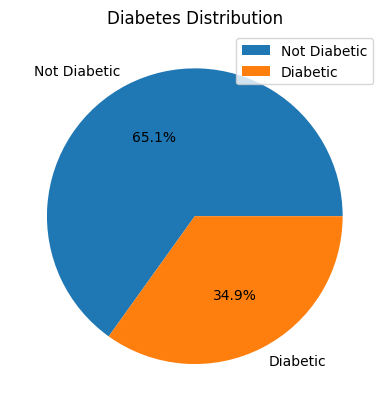

In [6]:
# Count the diabetic and non-diabetic patients in the data set.
values = df['Outcome'].value_counts()

# Print the number of diabetic and non-diabetic patients.
print(f"Number of diabetic patients: {values[1]}")
print(f"Number of non-diabetic patients: {values[0]}")

# Create a pie chart to show the distribution of diabetic and non-diabetic patients.
labels = 'Not Diabetic', 'Diabetic'

plt.pie(values, labels = labels, autopct='%1.1f%%')

# Add a legend and title for the chart.
plt.legend()
plt.title('Diabetes Distribution')

#Display the chart.
plt.show()

In [7]:
# List of colums with missing values.
missing_values = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace the zero(missing) values with NaN.
for column in missing_values:
    df.loc[df[column] == 0, column] = np.nan

# Display the new dataframe with NaN values.
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [8]:
# Count the number of missing values in every column.
missing_values_count = df.isnull().sum()
# Display the number of missing values in every column.
missing_values_count

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Handling Missing Values

To perform a detailed analysis on the diabetes dataset, it is important that all fields contain valid values. Since the dataset contains missing data, these values need to be handled before analysis.

Missing values can be replaced using either the mean or the median. In this project, the median was chosen because several features are not normally distributed and contain outliers. Unlike the mean, the median is less affected by extreme values, making it a better choice for skewed data.

In [9]:
# Fill in the NaN values with the median value of the respective column.
for column in missing_values:
    df[column] = df[column].fillna(df[column].median())

df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,72.0,29.0,125.0,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1


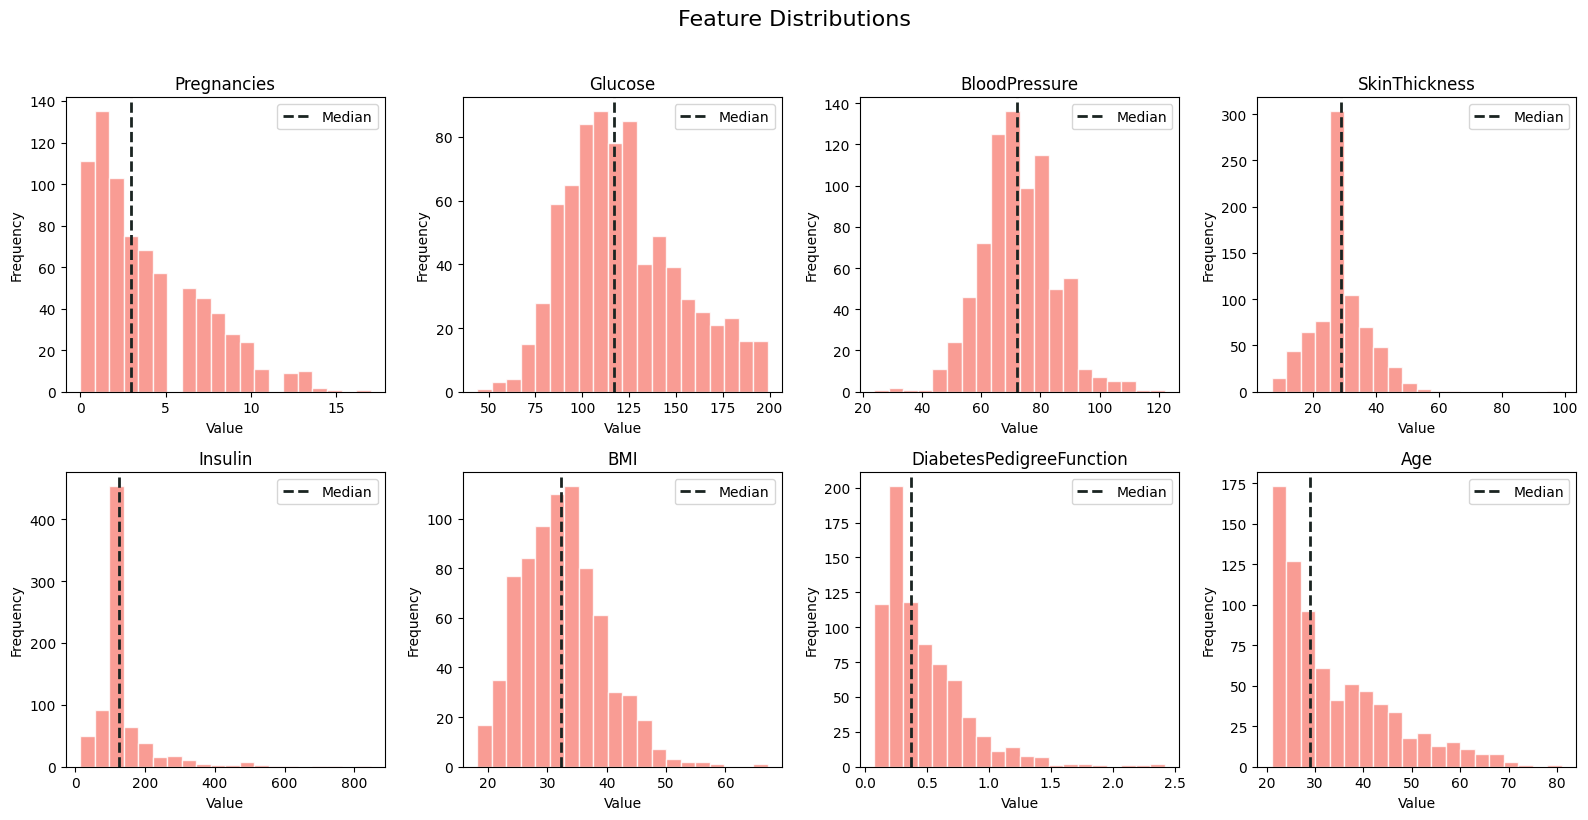

In [10]:
# Get a list of all the features in the dataset used to determine if a patient is diabetic or not.
features = df.columns[:-1]

# Plot the distribution of each feature.
figure, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, column in enumerate(features):
    axes[i].hist(df[column], bins=20, color='#F88379', edgecolor='#FFFFFF', alpha=0.8)
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[column].median(), color='#1A2421', linestyle='dashed', linewidth=2, label='Median')
    axes[i].legend()

# Add a title for the figure.
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
# Adjust the layout of the figure.
plt.tight_layout()
# Display the figure.
plt.show()

# Histograms Analysis
From the histogram distributions, it can be observed that the Insulin and DiabetesPedigreeFunction variables are strongly right-skewed, indicating the presence of extreme higher values and potential outliers. In contrast, the Glucose and BloodPressure variables appear closer to a normal distribution compared to the other features. Additionally, the Age distribution suggests that most patients included in the dataset are young adults, with fewer observations among older age groups.


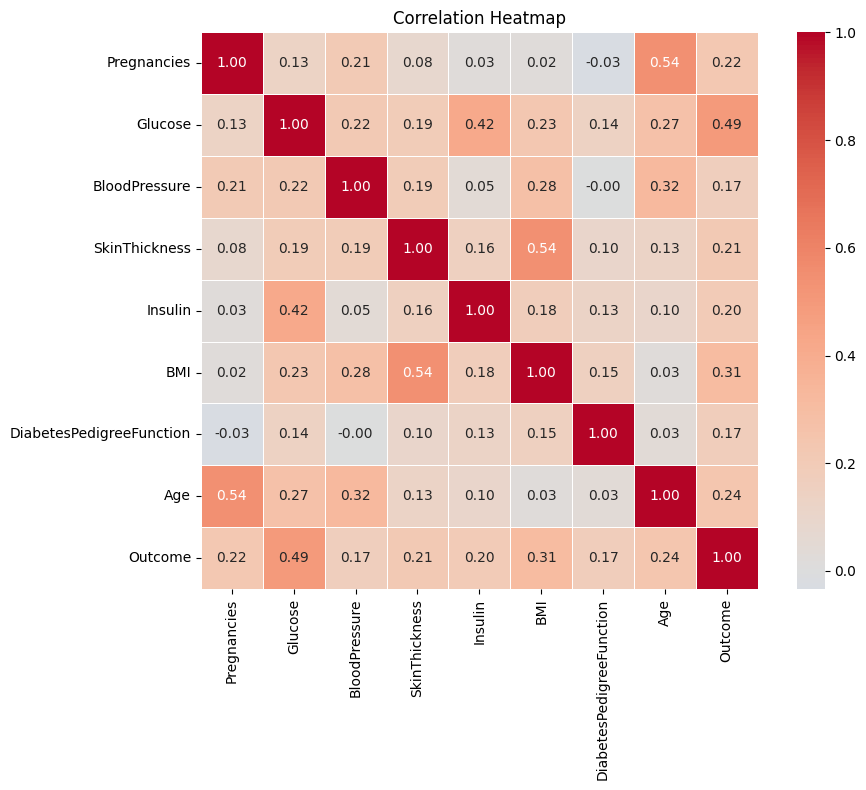

In [11]:
# Plot the correlation heatmap of the features.
plt.figure(figsize=(10, 8))
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, fmt='.2f',cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


# Heat Map Analysis
From the heatmap above, we can determine that there is a moderately strong positive relationship between a patient’s glucose levels and whether they are diabetic or not. This aligns with real-world medical knowledge, since diabetes is a disease closely associated with high blood glucose levels.

Another factor that may increase a patient’s likelihood of developing diabetes is BMI, which is used to determine whether a person is overweight or obese. This relationship is also realistic, as obesity is considered a major risk factor for diabetes and can contribute to increased blood glucose levels.

Lastly, age may also be a contributing factor to diabetes, as older patients tend to show a slightly higher likelihood of developing the disease. This may be related to age-associated metabolic changes and other health conditions that become more common over time.

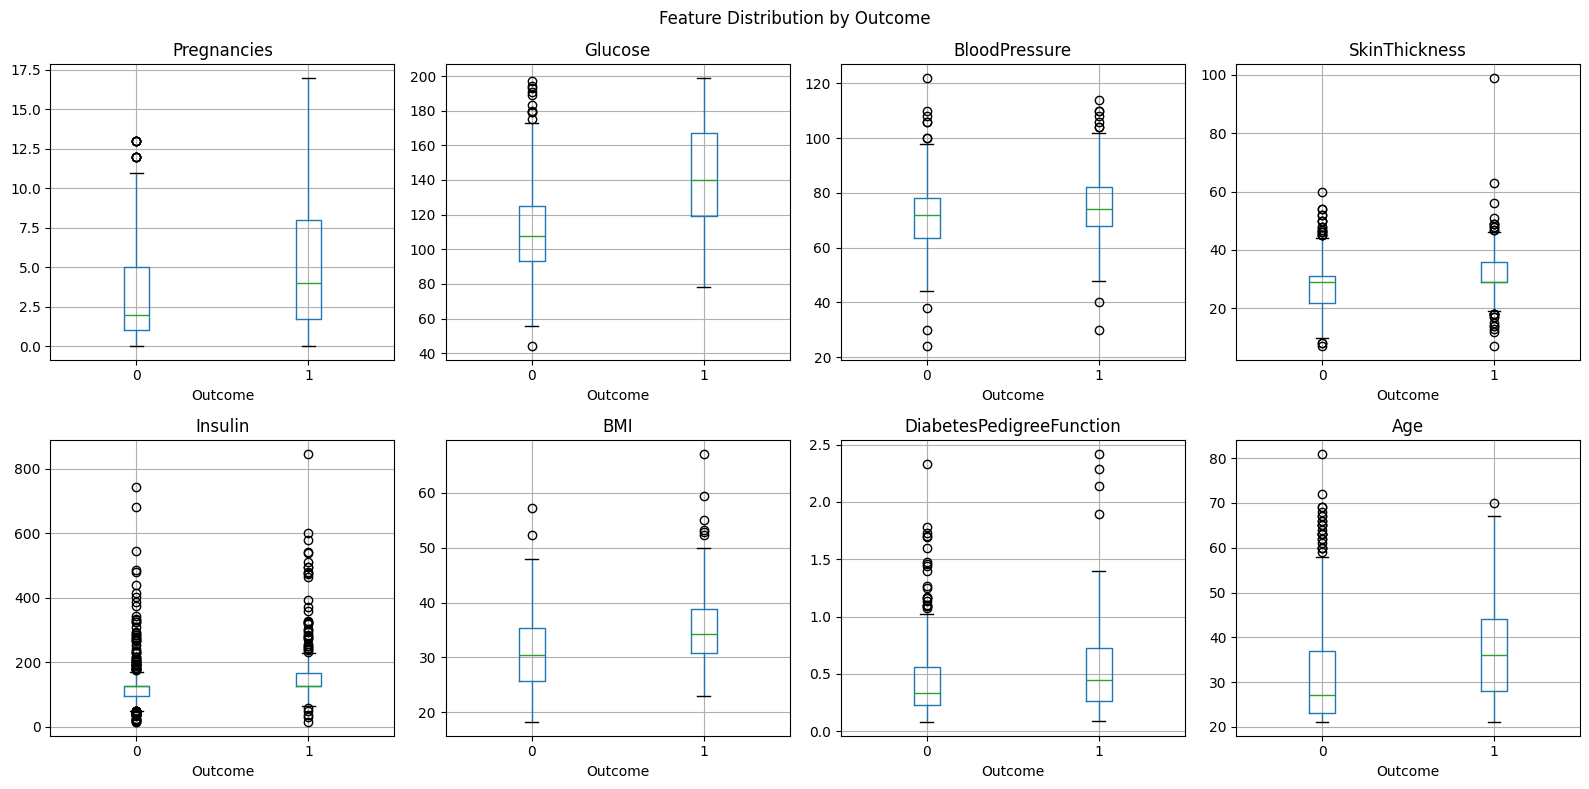

In [12]:
# Plot boxplots for each feature grouped by the 'Outcome' variable.
figure, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, column in enumerate(features):
    df.boxplot(column=column, by='Outcome', ax=axes[i])
    axes[i].set_title(column)
    axes[i].set_xlabel('Outcome')

plt.suptitle('Feature Distribution by Outcome')
plt.tight_layout()
plt.show()

# Box Plot Diagram Analysis
From the box plot above, we can determine that patients without diabetes may still present elevated blood glucose levels; however, these levels are considerably lower than those observed in diabetic patients.

Patients above the age of 40 appear to be more prone to diabetes than younger patients, although there are exceptions where patients over 40 are non-diabetic.

Non-diabetic patients generally exhibit lower insulin levels in their bloodstream compared to diabetic patients. However, some non-diabetic patients present insulin levels that are close to those observed in diabetic individuals, which explains the overlap between the two groups.

Additionally, diabetic patients tend to have slightly higher blood pressure and skin thickness values than non-diabetic patients, although the separation between these groups is less pronounced compared to glucose levels.

In [13]:
diabetic = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

# Create a table to display the results of the t-tests for each feature.
print(f"{'Feature':<28} {'T-stat':>8} {'P-value':>14} {'Significant':>25}")
print('-' * 80)

results = {}
# Go through all the features and perform a t-test to compare the means of the diabetic and non-diabetic groups for each feature.
for feat in features:
    # Perform a t-test for the current feature.
    t_stat, p_val = stats.ttest_ind(diabetic[feat], non_diabetic[feat], equal_var=False)
    # Determine if the result is statistically significant based on a p-value threshold of 0.5.
    significant = 'Yes' if p_val < 0.05 else 'No'
    # Store the p-value result in the result dictionary.
    results[feat] = p_val
    # Print the results for the current feature.
    print(f"{feat:<28} {t_stat:>8.3f} {p_val:>10.20f} {significant:>14}")

# Identify the most significant feature based on the lowest p-value.
best_feature = min(results, key=results.get)
print(f'\nThe best feature for predicting diabetes is: {best_feature} with a p-value of {results[best_feature]:.50f}')

Feature                        T-stat        P-value               Significant
--------------------------------------------------------------------------------
Pregnancies                     5.907 0.00000000682192560046            Yes
Glucose                        14.853 0.00000000000000000000            Yes
BloodPressure                   4.648 0.00000420167692126746            Yes
SkinThickness                   6.066 0.00000000247195849891            Yes
Insulin                         5.268 0.00000021991047453732            Yes
BMI                             9.052 0.00000000000000000255            Yes
DiabetesPedigreeFunction        4.577 0.00000610048142424034            Yes
Age                             6.921 0.00000000001201512527            Yes

The best feature for predicting diabetes is: Glucose with a p-value of 0.00000000000000000000000000000000000000003542148561


The T-Test performed proves that the difference between diabetic and non-diabetic pacient groups are statistically significant and unlikely to have occured by random chance alone.

Among all the features analyzed, Glucose shows the strongest statistical difference between the two groups, as it has the lowest p-value. This suggests that blood glucose level is one of the most important indicators associated with diabetes in the dataset.

In [14]:
x = df[features]
y = df['Outcome']

# Split the data into training and testing sets. The set is split 30% for testing and 70% for training the model.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=25)


In [15]:
# Create a logistic regression model.
lr = LogisticRegression()

In [ ]:
# Create a standard scaler to scale the features
scaler = StandardScaler()

In [ ]:
# Create a pipeline.
pipe = make_pipeline(scaler, lr)

# Final Insights

## Key Findings

Glucose showed the strongest relationship with diabetes outcome.

Patients that have diabetes have a slightly higher BMI.

BMI and Insulin also displayed meaningful differences.

Several medical variables were right-skewed and contained outliers.

## Limitations

The dataset size is relatively small.

Correlation does not imply causation.

Statistical assumptions were not fully validated.